<a href="https://colab.research.google.com/github/Karthik5412/Shopping-Cart/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns

In [27]:
df = pd.read_csv('/content/products.csv')
df.head()

,product_id,brand,title,price,category,rating,image_url,product_url
0,B08YRWN3WB,JANSPORT,Big Student Large laptop backpack Black EK0A5B...,189.00,New season,4.7,https://m.media-amazon.com/images/I/51y2EF0OmO...,https://www.amazon.ae/dp/B08YRWN3WB
1,B08YRXFZZM,JANSPORT,Superbreak Day Pack,119.00,New season,4.6,https://m.media-amazon.com/images/I/51yvvQUs3S...,https://www.amazon.ae/dp/B08YRXFZZM
2,B09Q2PQ7ZB,BAODINI,Mini Travel Umbrella With Case Small Compact U...,17.79,New season,4.2,https://m.media-amazon.com/images/I/71WbrZPbnG...,https://www.amazon.ae/dp/B09Q2PQ7ZB
3,B001BEAWXY,Calvin Klein,Men's Cotton Classics 3-Pack Boxer Brief,119.00,New season,4.2,https://m.media-amazon.com/images/I/716vzeqa7Z...,https://www.amazon.ae/dp/B001BEAWXY
4,B09FM5PMN3,JANSPORT,Unisex Kids Bag Backpack,179.00,New season,4.4,https://m.media-amazon.com/images/I/51XASBuqjr...,https://www.amazon.ae/dp/B09FM5PMN3


In [28]:
print(df.shape)
df.info()

(13156, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13156 entries, 0 to 13155
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   13156 non-null  object 
 1   brand        13155 non-null  object 
 2   title        13155 non-null  object 
 3   price        12963 non-null  float64
 4   category     13156 non-null  object 
 5   rating       12273 non-null  float64
 6   image_url    13156 non-null  object 
 7   product_url  13156 non-null  object 
dtypes: float64(2), object(6)
memory usage: 822.4+ KB


In [29]:
df = df.dropna()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12085 entries, 0 to 13154
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   12085 non-null  object 
 1   brand        12085 non-null  object 
 2   title        12085 non-null  object 
 3   price        12085 non-null  float64
 4   category     12085 non-null  object 
 5   rating       12085 non-null  float64
 6   image_url    12085 non-null  object 
 7   product_url  12085 non-null  object 
dtypes: float64(2), object(6)
memory usage: 849.7+ KB


In [31]:
df.to_csv('cleaned.csv')

In [32]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [33]:
stop_words = set(stopwords.words('english'))
lematizer = WordNetLemmatizer()

In [34]:
def preprocessing_text(data : str) -> str:

    #Lower Case
    data = str(data).lower()

    #Remove punctuations
    data = re.sub(r'[^a-zA-z\s]', "",data)

    #Words split
    words = data.split()

    #removing stopwords
    words = [word for word in words if word not in stop_words]

    #Lematization
    words = [lematizer.lemmatize(word) for word in words]

    return ' '.join(words)

In [35]:
df['brand'] = df['brand'].apply(preprocessing_text)
df['title'] = df['title'].apply(preprocessing_text)
df['category'] = df['category'].astype(object).apply(preprocessing_text)

df.head()

,product_id,brand,title,price,category,rating,image_url,product_url
0,B08YRWN3WB,jansport,big student large laptop backpack black ekabahn,189.00,new season,4.7,https://m.media-amazon.com/images/I/51y2EF0OmO...,https://www.amazon.ae/dp/B08YRWN3WB
1,B08YRXFZZM,jansport,superbreak day pack,119.00,new season,4.6,https://m.media-amazon.com/images/I/51yvvQUs3S...,https://www.amazon.ae/dp/B08YRXFZZM
2,B09Q2PQ7ZB,baodini,mini travel umbrella case small compact uv umb...,17.79,new season,4.2,https://m.media-amazon.com/images/I/71WbrZPbnG...,https://www.amazon.ae/dp/B09Q2PQ7ZB
3,B001BEAWXY,calvin klein,men cotton classic pack boxer brief,119.00,new season,4.2,https://m.media-amazon.com/images/I/716vzeqa7Z...,https://www.amazon.ae/dp/B001BEAWXY
4,B09FM5PMN3,jansport,unisex kid bag backpack,179.00,new season,4.4,https://m.media-amazon.com/images/I/51XASBuqjr...,https://www.amazon.ae/dp/B09FM5PMN3


In [36]:
df

,product_id,brand,title,price,category,rating,image_url,product_url
0,B08YRWN3WB,jansport,big student large laptop backpack black ekabahn,189.00,new season,4.7,https://m.media-amazon.com/images/I/51y2EF0OmO...,https://www.amazon.ae/dp/B08YRWN3WB
1,B08YRXFZZM,jansport,superbreak day pack,119.00,new season,4.6,https://m.media-amazon.com/images/I/51yvvQUs3S...,https://www.amazon.ae/dp/B08YRXFZZM
2,B09Q2PQ7ZB,baodini,mini travel umbrella case small compact uv umb...,17.79,new season,4.2,https://m.media-amazon.com/images/I/71WbrZPbnG...,https://www.amazon.ae/dp/B09Q2PQ7ZB
3,B001BEAWXY,calvin klein,men cotton classic pack boxer brief,119.00,new season,4.2,https://m.media-amazon.com/images/I/716vzeqa7Z...,https://www.amazon.ae/dp/B001BEAWXY
4,B09FM5PMN3,jansport,unisex kid bag backpack,179.00,new season,4.4,https://m.media-amazon.com/images/I/51XASBuqjr...,https://www.amazon.ae/dp/B09FM5PMN3
...,...,...,...,...,...,...,...,...
13150,B01M0J414M,lieblich,huggie stud earring black small hoop stainless...,43.08,accessory,4.5,https://m.media-amazon.com/images/I/61C-XNteze...,https://www.amazon.ae/dp/B01M0J414M
13151,B000QULS3M,sabona,men stainless steel magnetic bracelet sport ma...,193.82,accessory,4.2,https://m.media-amazon.com/images/I/51+6l3CD4E...,https://www.amazon.ae/dp/B000QULS3M
13152,B07VYZ6PFH,u,sterling silver k gold plated oval miraculous ...,206.00,accessory,4.7,https://m.media-amazon.com/images/I/71uutEyhD4...,https://www.amazon.ae/dp/B07VYZ6PFH
13153,B09BK5CNC3,tommy hilfiger,round braided bracelet men leather bracelet,110.00,accessory,4.5,https://m.media-amazon.com/images/I/71CbQ4Sixb...,https://www.amazon.ae/dp/B09BK5CNC3


In [37]:
df['Final pharse'] = df['brand'] + df['title'] +df['category']
df

,product_id,brand,title,price,category,rating,image_url,product_url,Final pharse
0,B08YRWN3WB,jansport,big student large laptop backpack black ekabahn,189.00,new season,4.7,https://m.media-amazon.com/images/I/51y2EF0OmO...,https://www.amazon.ae/dp/B08YRWN3WB,jansportbig student large laptop backpack blac...
1,B08YRXFZZM,jansport,superbreak day pack,119.00,new season,4.6,https://m.media-amazon.com/images/I/51yvvQUs3S...,https://www.amazon.ae/dp/B08YRXFZZM,jansportsuperbreak day packnew season
2,B09Q2PQ7ZB,baodini,mini travel umbrella case small compact uv umb...,17.79,new season,4.2,https://m.media-amazon.com/images/I/71WbrZPbnG...,https://www.amazon.ae/dp/B09Q2PQ7ZB,baodinimini travel umbrella case small compact...
3,B001BEAWXY,calvin klein,men cotton classic pack boxer brief,119.00,new season,4.2,https://m.media-amazon.com/images/I/716vzeqa7Z...,https://www.amazon.ae/dp/B001BEAWXY,calvin kleinmen cotton classic pack boxer brie...
4,B09FM5PMN3,jansport,unisex kid bag backpack,179.00,new season,4.4,https://m.media-amazon.com/images/I/51XASBuqjr...,https://www.amazon.ae/dp/B09FM5PMN3,jansportunisex kid bag backpacknew season
...,...,...,...,...,...,...,...,...,...
13150,B01M0J414M,lieblich,huggie stud earring black small hoop stainless...,43.08,accessory,4.5,https://m.media-amazon.com/images/I/61C-XNteze...,https://www.amazon.ae/dp/B01M0J414M,lieblichhuggie stud earring black small hoop s...
13151,B000QULS3M,sabona,men stainless steel magnetic bracelet sport ma...,193.82,accessory,4.2,https://m.media-amazon.com/images/I/51+6l3CD4E...,https://www.amazon.ae/dp/B000QULS3M,sabonamen stainless steel magnetic bracelet sp...
13152,B07VYZ6PFH,u,sterling silver k gold plated oval miraculous ...,206.00,accessory,4.7,https://m.media-amazon.com/images/I/71uutEyhD4...,https://www.amazon.ae/dp/B07VYZ6PFH,usterling silver k gold plated oval miraculous...
13153,B09BK5CNC3,tommy hilfiger,round braided bracelet men leather bracelet,110.00,accessory,4.5,https://m.media-amazon.com/images/I/71CbQ4Sixb...,https://www.amazon.ae/dp/B09BK5CNC3,tommy hilfigerround braided bracelet men leath...


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
tfidf = TfidfVectorizer(max_features= 5000, ngram_range=(1,2), stop_words= 'english')

In [40]:
matrix = tfidf.fit_transform(df['Final pharse'])

In [41]:
matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 128041 stored elements and shape (12085, 5000)>

In [42]:
n = len(df['category'].unique())
n

11

In [43]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters= n, init= 'k-means++')

In [44]:
clusters = model.fit_predict(matrix)

In [45]:
clusters

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

In [46]:
df['clusters'] = clusters
df

,product_id,brand,title,price,category,rating,image_url,product_url,Final pharse,clusters
0,B08YRWN3WB,jansport,big student large laptop backpack black ekabahn,189.00,new season,4.7,https://m.media-amazon.com/images/I/51y2EF0OmO...,https://www.amazon.ae/dp/B08YRWN3WB,jansportbig student large laptop backpack blac...,1
1,B08YRXFZZM,jansport,superbreak day pack,119.00,new season,4.6,https://m.media-amazon.com/images/I/51yvvQUs3S...,https://www.amazon.ae/dp/B08YRXFZZM,jansportsuperbreak day packnew season,1
2,B09Q2PQ7ZB,baodini,mini travel umbrella case small compact uv umb...,17.79,new season,4.2,https://m.media-amazon.com/images/I/71WbrZPbnG...,https://www.amazon.ae/dp/B09Q2PQ7ZB,baodinimini travel umbrella case small compact...,1
3,B001BEAWXY,calvin klein,men cotton classic pack boxer brief,119.00,new season,4.2,https://m.media-amazon.com/images/I/716vzeqa7Z...,https://www.amazon.ae/dp/B001BEAWXY,calvin kleinmen cotton classic pack boxer brie...,1
4,B09FM5PMN3,jansport,unisex kid bag backpack,179.00,new season,4.4,https://m.media-amazon.com/images/I/51XASBuqjr...,https://www.amazon.ae/dp/B09FM5PMN3,jansportunisex kid bag backpacknew season,1
...,...,...,...,...,...,...,...,...,...,...
13150,B01M0J414M,lieblich,huggie stud earring black small hoop stainless...,43.08,accessory,4.5,https://m.media-amazon.com/images/I/61C-XNteze...,https://www.amazon.ae/dp/B01M0J414M,lieblichhuggie stud earring black small hoop s...,8
13151,B000QULS3M,sabona,men stainless steel magnetic bracelet sport ma...,193.82,accessory,4.2,https://m.media-amazon.com/images/I/51+6l3CD4E...,https://www.amazon.ae/dp/B000QULS3M,sabonamen stainless steel magnetic bracelet sp...,8
13152,B07VYZ6PFH,u,sterling silver k gold plated oval miraculous ...,206.00,accessory,4.7,https://m.media-amazon.com/images/I/71uutEyhD4...,https://www.amazon.ae/dp/B07VYZ6PFH,usterling silver k gold plated oval miraculous...,1
13153,B09BK5CNC3,tommy hilfiger,round braided bracelet men leather bracelet,110.00,accessory,4.5,https://m.media-amazon.com/images/I/71CbQ4Sixb...,https://www.amazon.ae/dp/B09BK5CNC3,tommy hilfigerround braided bracelet men leath...,1


<Axes: xlabel='price', ylabel='rating'>

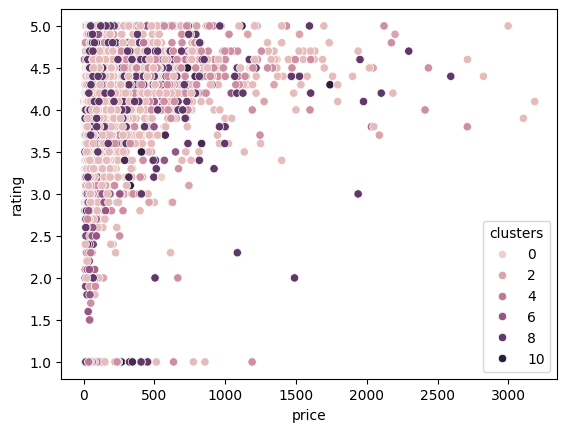

In [47]:
sns.scatterplot(x= df['price'], y= df['rating'], hue= df['clusters'] )

In [48]:
import pickle

pickle.dump(tfidf, open('tfidf.plk', 'wb'))
pickle.dump(model, open('kmeans.plk', 'wb'))

df.to_csv('final_dataset.csv')